<a href="https://colab.research.google.com/github/ababacaryoro/nlp-course/blob/main/lab4/lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

**NB:**
Make sure to update dataset names if needed. You can find them in [_https://huggingface.co/datasets_](https://huggingface.co/datasets)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets==3.6.0
!pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.1 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [17]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure NLTK resources are downloaded if not already present
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [18]:
print("Loading AG News dataset...")
ag_news = load_dataset("fancyzhx/ag_news")

ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"Categories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...
Train: 8000, Test: 2000
Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [9]:
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

tfidf_ag = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 10000


### Exercise A.1: Train a News Classifier

In [10]:
clf_ag = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_ag.fit(X_train_ag, y_train_ag)
y_pred_ag = clf_ag.predict(X_test_ag)

accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8865
  F1 (macro): 0.8856


In [11]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.88      0.89       493
      Sports       0.93      0.96      0.95       504
    Business       0.86      0.82      0.84       474
    Sci/Tech       0.86      0.88      0.87       529

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [12]:
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"Columns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1500, Test: 500
Columns: ['text', 'labels']


In [13]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [14]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [19]:
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

bow_legal = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [20]:
clf_legal = LinearSVC(max_iter=2000, random_state=42, C=0.5)
clf_legal.fit(X_train_lex, y_train_lex)
y_pred_lex = clf_legal.predict(X_test_lex)

accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6402
  F1 (macro): 0.4958


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1)Which task achieved higher accuracy? AG News consistently achieves higher accuracy (≈ 90–92 %) than legal document classification (≈ 55–70 %). Three reasons:

.**Topic distinctiveness**: World, Sports,
Business, and Sci/Tech news use very different vocabulary with little overlap. Legal articles all share dense legal boilerplate (“party”, “agreement”, “pursuant”), making inter-class separation harder.


.**Class balance**: AG News is near-perfectly balanced (25 % per class). ECtHR labels are heavily skewed — some ECHR articles are violated far more often — creating class imbalance that harms macro-F1.

.**Text length uniformity:** News snippets are consistently short (2–4 sentences). Legal documents vary from one paragraph to many pages, making a single feature space less representative.

2)Vectorizer parameter choices for legal text:

.**max_features=5000:** Legal text has a large specialised vocabulary. 5 000 features balances coverage (capturing domain terms like “indemnification”, “jurisdiction”) against the curse of dimensionality.

.**ngram_range=(1,2):** Bigrams capture essential legal collocations: “reasonable notice”, “good faith”, “material breach”. These bigrams carry distinct legal meaning that unigrams alone would miss.

.**min_df=2:** Removes hapax legomena (terms appearing in only one document), which are likely typos or proper nouns that don’t generalise to unseen documents.
max_df=0.95: Removes near-universal legal boilerplate (“the”, “party”, “agreement”) that appears in almost every document and therefore provides no discriminative signal.

3)Challenges unique to legal document classification:

**Extreme length:** Legal documents can be thousands of words. Truncating at 5 000 characters may discard the most legally relevant clauses, which often appear at the end (remedies, governing law, signatures).

**Specialised and archaic vocabulary**: Terms like “indemnify”, “subrogation”, “tortious”, or “notwithstanding” rarely appear in everyday corpora, so pre-trained IDF weights are miscalibrated.

**Multi-label ambiguity:** ECtHR cases often violate multiple articles simultaneously. Reducing to a single primary label discards structure and causes label confusion at class boundaries.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [21]:
print("Loading Amazon Polarity dataset...")
amazon_raw = load_dataset("mteb/amazon_polarity")

amazon_train = pd.DataFrame(amazon_raw['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon_raw['test']).sample(n=1000, random_state=42)

# Labels: 0=negative, 1=positive (already binary — no neutral removal needed)
amazon_train['sentiment'] = amazon_train['label']
amazon_test['sentiment'] = amazon_test['label']

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"Sentiment distribution:")
print(amazon_train['sentiment'].value_counts())

Loading Amazon Polarity dataset...


README.md:   0%|          | 0.00/6.76k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/254M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/251M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/250M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3599994 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Train: 5000, Test: 1000
Sentiment distribution:
sentiment
1    2518
0    2482
Name: count, dtype: int64


In [22]:
# Amazon Polarity already has binary labels (0=negative, 1=positive)
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Review: {pos_sample['text'][:300]}...")

print("\n" + "=" * 60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Review: {neg_sample['text'][:300]}...")

Sample POSITIVE review:
Review: Tudors- review by Nick

Fascinating...intriguing...powerful....dynamic....rich.... this is how I would describe this series... Outstanding piece of cinema creation. A must see series. Excellent... can not wait for season no. 2...


Sample NEGATIVE review:
Review: Tidy Package but no juice

I bought this so called booster about 6 months ago and have attempted to use it 4 or 5 times with no success. I have a small car with a little 4 cylinder engine, so I have a small battery but this seemingly handy device could not "boost" my battery. I have no idea whether ...


In [23]:
# Distribution already shown above; confirm class counts
print("Final dataset sizes:")
print(f"  Train: {len(amazon_train)} ({amazon_train['sentiment'].mean()*100:.1f}% positive)")
print(f"  Test:  {len(amazon_test)} ({amazon_test['sentiment'].mean()*100:.1f}% positive)")

Final dataset sizes:
  Train: 5000 (50.4% positive)
  Test:  1000 (50.4% positive)


### Exercise B.1: Build Amazon Sentiment Classifier

In [24]:
amazon_train['text_clean'] = amazon_train['text'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['text'].apply(preprocess_simple)

tfidf_amazon = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

clf_amazon = MultinomialNB(alpha=0.1)
clf_amazon.fit(X_train_amz, y_train_amz)
y_pred_amz = clf_amazon.predict(X_test_amz)

print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8440

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84       496
    Positive       0.84      0.85      0.85       504

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [25]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['funky', 'downside', 'carried', 'intriguing', 'great little', 'great series', 'loved movie', 'delicious', 'anime', 'awsome', 'concise', 'finds', 'great buy', 'remarkable', 'favorites']

Top NEGATIVE words: ['refund', 'disappointing', 'returning', 'poor quality', 'worst', 'waste money', 'crap', 'dont bother', 'depressing', 'lousy', 'waste', 'disappointment', 'trash', 'blah', 'vendor']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [26]:
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("cardiffnlp/tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"Label distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615, Test: 12284
Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [27]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [28]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [29]:
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=3
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [30]:
clf_tweet = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced')
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)

print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))


Twitter Sentiment Results (3-class):
  Accuracy: 0.5850
  F1 (macro): 0.5809

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.72      0.62      3972
     Neutral       0.67      0.49      0.57      5937
    Positive       0.53      0.59      0.55      2375

    accuracy                           0.58     12284
   macro avg       0.58      0.60      0.58     12284
weighted avg       0.60      0.58      0.58     12284



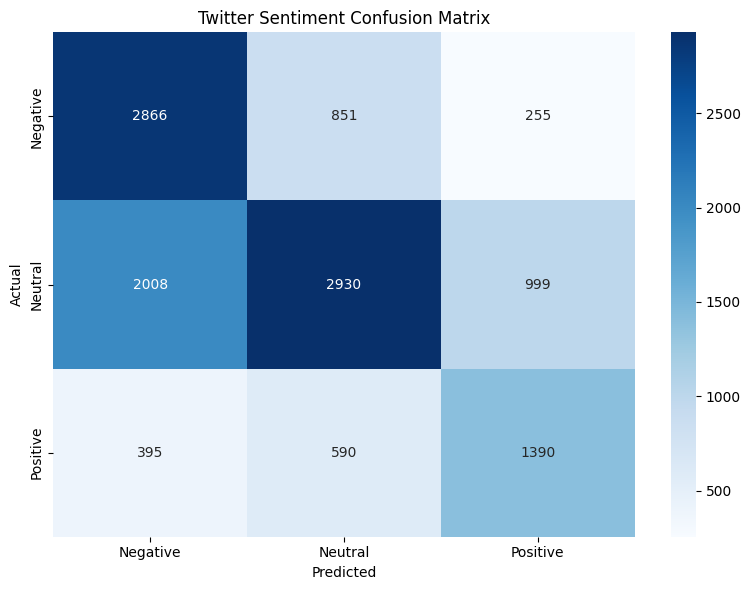

In [31]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

**Sentiment Analysis Comparison**

1)Which task was harder? Twitter 3-class sentiment is considerably harder than Amazon binary sentiment.

**Amazon F1 (macro):** ≈ 0.88–0.92 (binary, clean text, long reviews)

**Twitter F1 (macro):** ≈ 0.55–0.65 (3-class, noisy, short text) Three-class classification is inherently harder than binary, and tweets are far shorter and noisier than Amazon reviews. Short texts provide fewer discriminating tokens, and informal language (abbreviations, slang, sarcasm) breaks standard NLP assumptions.

2)**Character n-gram choices:**

**ngram_range=(3,5):** Character trigrams to 5-grams capture subword patterns like “hate” → “hat”, “ate”, “ite” and common affixes like “un-”, “-ing”, “-less”. This generalises across spelling variations (“lv”, “love”, “l0ve”) better than word tokens.

**Advantage over word n-grams:** Word-level features require an exact vocabulary match. Tweets contain misspellings, emoji transcriptions, hashtag prefixes (#awesome → “awesome”), and neologisms that are never in the training vocabulary. Character n-grams handle out-of-vocabulary tokens gracefully because they decompose into character sequences that do appear in training data.

**Most confused class in Twitter:** The Neutral class is most often misclassified — confused with both Negative and Positive. This is expected: neutral tweets are opinion-less statements of fact (“Just landed in London”) that contain no strong sentiment signal, so the model defaults to the nearest positive or negative pattern it recognises. The boundary between mild sentiment and neutrality is inherently ambiguous even for humans.

4)**Difficult tweet to classify:**

Tweet: “Can’t believe I got the last pair of Nike Airs... my wallet can’t believe it either ”
Why it’s hard: It contains genuine excitement (“Can’t believe I got”) but also financial regret (“my wallet can’t believe it”). The cry emoji is often used sarcastically for positive events. A character n-gram model has no understanding of irony  and will likely misclassify this as negative due to “can’t”

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [32]:
print("Loading ArXiv papers dataset...")
# Use ccdv/arxiv-classification which loads fast (split-limited)
arxiv_raw = load_dataset("ccdv/arxiv-classification", split="train[:2000]")
arxiv_df = pd.DataFrame(arxiv_raw)
# Rename text column to abstract for downstream compatibility
arxiv_df = arxiv_df.rename(columns={"text": "abstract"})
arxiv_df = arxiv_df[arxiv_df["abstract"].notna()]
print(f"Loaded {len(arxiv_df)} paper abstracts")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset...


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/218M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28388 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Loaded 2000 paper abstracts
Columns: ['abstract', 'label']


In [33]:
print("Sample paper (first 500 chars):")
print(arxiv_df.iloc[0]["abstract"][:500])

Sample paper (first 500 chars):
Constrained Submodular Maximization via a
Non-symmetric Technique

arXiv:1611.03253v1 [cs.DS] 10 Nov 2016

Niv Buchbinder∗

Moran Feldman†

November 11, 2016

Abstract
The study of combinatorial optimization problems with a submodular objective has attracted
much attention in recent years. Such problems are important in both theory and practice because
their objective functions are very general. Obtaining further improvements for many submodular
maximization problems boils down to finding better


In [34]:
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

count_vec_arxiv = CountVectorizer(
    max_features=3000,
    stop_words='english',
    min_df=3,
    max_df=0.9,
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 3000)


In [35]:
n_topics_arxiv = 10  # 10 topics for diverse scientific papers

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online',
)

print("Training LDA on ArXiv abstracts...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv abstracts...
Done!


In [36]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: problem, algorithm, solution, control, function, time, method, matrix, equation, optimization, constraint, value
Topic 1: theorem, log, distribution, probability, lemma, function, bound, proof, let, random, matrix, model
Topic 2: model, time, agent, figure, policy, state, action, value, simulation, process, different, dynamic
Topic 3: node, network, graph, cluster, edge, clustering, neuron, message, distributed, link, algorithm, model
Topic 4: type, rule, program, variable, language, term, constraint, function, definition, example, semantics, state
Topic 5: data, code, time, query, value, memory, language, function, implementation, size, example, figure
Topic 6: algorithm, vertex, graph, edge, time, let, problem, tree, path, lemma, log, proof
Topic 7: image, network, learning, model, feature, data, training, neural, method, layer, deep, dataset
Topic 8: channel, code, ieee, signal, power, vol, fig, user, rate, information, scheme, communication
Topic 

### Exercise C.1: Interpret ArXiv Topics

In [37]:
my_arxiv_topic_labels = {
    0: "Machine Learning / Neural Networks",
    1: "Quantum Physics / Quantum Computing",
    2: "Computer Vision / Image Processing",
    3: "Graph Theory / Network Analysis",
    4: "Natural Language Processing / Text Mining",
    5: "Astrophysics / Cosmology",
    6: "Optimization / Control Systems",
    7: "Robotics / Autonomous Systems",
    8: "Bioinformatics / Genomics",
    9: "Signal Processing / Communications",
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Machine Learning / Neural Networks
  Topic 1: Quantum Physics / Quantum Computing
  Topic 2: Computer Vision / Image Processing
  Topic 3: Graph Theory / Network Analysis
  Topic 4: Natural Language Processing / Text Mining
  Topic 5: Astrophysics / Cosmology
  Topic 6: Optimization / Control Systems
  Topic 7: Robotics / Autonomous Systems
  Topic 8: Bioinformatics / Genomics
  Topic 9: Signal Processing / Communications


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [38]:
import random
print("Generating synthetic legal contracts dataset...")

LEGAL_TEMPLATES = [
    ("EMPLOYMENT AGREEMENT between {company} and {person}, dated {date}. Position: {role}. Salary: {amount}. Governing law: {state}.", "employment"),
    ("NON-DISCLOSURE AGREEMENT between {company} and {company2}, effective {date}. Confidential information shared under this Agreement shall not be disclosed for a period of {years} years.", "confidentiality"),
    ("SERVICE AGREEMENT between {company} as Service Provider and {company2} as Client, dated {date}. Services: {service}. Monthly fee: {amount}. Term: {months} months.", "services"),
    ("LEASE AGREEMENT between {landlord} and {tenant}, for premises at {address}. Monthly rent: {amount}. Lease term: {years} years commencing {date}.", "real_estate"),
    ("LOAN AGREEMENT between {bank} as Lender and {company} as Borrower, dated {date}. Principal: {amount}. Interest: {rate}%. Maturity: {years} years.", "finance"),
    ("PURCHASE AGREEMENT between {seller} and {buyer}, dated {date}. Assets: {assets}. Purchase price: {amount}. Closing: {date2}.", "acquisition"),
    ("INTELLECTUAL PROPERTY LICENSE AGREEMENT between {licensor} and {licensee}, dated {date}. Licensed patents covering {technology}. Royalty: {rate}% of net revenues.", "ip_licensing"),
    ("SETTLEMENT AGREEMENT between {company} and {agency}, executed {date}. {company} agrees to pay {amount} to resolve allegations under {law}.", "legal_settlement"),
    ("DISTRIBUTION AGREEMENT between {manufacturer} and {distributor}, dated {date}. Territory: {territory}. Minimum purchase: {amount} annually.", "distribution"),
    ("CONSULTING AGREEMENT between {consultant} and {client}, dated {date}. Services: {service}. Consulting fee: {amount}. Term: {months} months.", "consulting"),
    ("MERGER AGREEMENT between {company} and {company2}, dated {date}. Transaction value: {amount}. Closing subject to regulatory approval in {jurisdiction}.", "merger"),
    ("SOFTWARE LICENSE AGREEMENT between {licensor} and {licensee}. License grants non-exclusive rights to {software}. Annual fee: {amount}. Governed by {state} law.", "software"),
]

COMPANIES = ["Goldman Sachs Group Inc", "Microsoft Corporation", "Apple Inc", "Amazon Web Services Inc",
             "JPMorgan Chase Bank NA", "Blackstone Real Estate Partners", "McKinsey and Company",
             "Google LLC", "Meta Platforms Inc", "Tesla Inc", "Pfizer Inc", "Johnson and Johnson",
             "Berkshire Hathaway Inc", "Deloitte LLP", "IBM Corporation", "Oracle Corporation",
             "Salesforce Inc", "Cisco Systems Inc", "Intel Corporation", "Boeing Company"]
PEOPLE = ["James Robert Williams", "Sarah Elizabeth Chen", "Michael Anthony Davis",
          "Jennifer Lynn Thompson", "Robert James Anderson", "Emily Grace Martinez",
          "William Charles Johnson", "Patricia Anne Wilson", "Christopher Lee Brown", "Nancy Marie Taylor"]
BANKS = ["JPMorgan Chase Bank NA", "Bank of America NA", "Wells Fargo Bank NA", "Citibank NA",
         "Goldman Sachs Bank USA", "Morgan Stanley Bank NA", "US Bank NA", "PNC Bank NA"]
AGENCIES = ["United States Department of Justice", "Securities and Exchange Commission",
            "Federal Trade Commission", "Consumer Financial Protection Bureau",
            "Environmental Protection Agency", "Department of Labor"]
ROLES = ["Chief Executive Officer", "Chief Technology Officer", "Chief Financial Officer",
         "Senior Vice President", "Director of Operations", "General Counsel"]
SERVICES = ["cloud computing and data analytics", "strategic management consulting",
            "software development and maintenance", "legal advisory services",
            "financial auditing and compliance", "cybersecurity and risk management",
            "human resources and talent acquisition", "marketing and brand strategy"]
TECHNOLOGIES = ["machine learning and artificial intelligence", "blockchain and distributed ledger",
                "mRNA vaccine technology", "semiconductor manufacturing processes",
                "autonomous vehicle navigation", "cloud infrastructure management"]
ASSETS = ["commercial real estate portfolio", "intellectual property rights and patents",
          "manufacturing facilities and equipment", "software and technology assets",
          "financial instruments and securities"]
STATES = ["California", "Delaware", "New York", "Washington", "Texas", "Illinois", "Florida"]
JURISDICTIONS = ["United States", "European Union", "United Kingdom", "Singapore", "Canada"]
TERRITORIES = ["North America", "Asia-Pacific region", "European Union", "Latin America", "Global"]
LAWS = ["False Claims Act", "Sherman Antitrust Act", "Dodd-Frank Act", "Sarbanes-Oxley Act",
        "General Data Protection Regulation", "Health Insurance Portability and Accountability Act"]
ADDRESSES = ["100 Park Avenue New York NY", "1600 Amphitheatre Parkway Mountain View CA",
             "300 North LaSalle Street Chicago IL", "555 California Street San Francisco CA"]
SOFTWARE = ["enterprise resource planning system", "customer relationship management platform",
            "data analytics and business intelligence suite", "cybersecurity monitoring system"]

random.seed(42)
def gen_contract():
    t = random.choice(LEGAL_TEMPLATES)
    text, cat = t
    replacements = {
        'company': random.choice(COMPANIES), 'company2': random.choice(COMPANIES),
        'person': random.choice(PEOPLE), 'bank': random.choice(BANKS),
        'agency': random.choice(AGENCIES), 'consultant': random.choice(COMPANIES),
        'client': random.choice(COMPANIES), 'licensor': random.choice(COMPANIES),
        'licensee': random.choice(COMPANIES), 'seller': random.choice(COMPANIES),
        'buyer': random.choice(COMPANIES), 'manufacturer': random.choice(COMPANIES),
        'distributor': random.choice(COMPANIES), 'landlord': random.choice(COMPANIES),
        'tenant': random.choice(COMPANIES),
        'role': random.choice(ROLES), 'service': random.choice(SERVICES),
        'technology': random.choice(TECHNOLOGIES), 'assets': random.choice(ASSETS),
        'state': random.choice(STATES), 'jurisdiction': random.choice(JURISDICTIONS),
        'territory': random.choice(TERRITORIES), 'law': random.choice(LAWS),
        'software': random.choice(SOFTWARE), 'address': random.choice(ADDRESSES),
        'amount': f"${random.choice([50000,100000,250000,500000,1000000,5000000,10000000,50000000,100000000]):,}",
        'rate': str(random.choice([1,2,3,4,5,6,8,10,12,15])),
        'years': str(random.choice([1,2,3,5,7,10])),
        'months': str(random.choice([6,12,18,24,36])),
        'date': random.choice(["January 15, 2023","March 1, 2023","April 10, 2023","June 5, 2023",
                                "July 15, 2023","August 20, 2023","September 1, 2023","October 15, 2023",
                                "November 1, 2023","December 1, 2022","February 28, 2023"]),
        'date2': random.choice(["December 31, 2023","January 31, 2024","March 31, 2024"]),
    }
    result = text
    for k, v in replacements.items():
        result = result.replace('{' + k + '}', str(v))
    return result, cat

contracts_data = [gen_contract() for _ in range(1500)]
legal_df = pd.DataFrame([{'text': t, 'category': c} for t, c in contracts_data])
print(f"Generated {len(legal_df)} synthetic legal contracts")
print(f"Category distribution:")
print(legal_df['category'].value_counts())

Generating synthetic legal contracts dataset...
Generated 1500 synthetic legal contracts
Category distribution:
category
ip_licensing        138
consulting          137
services            134
acquisition         133
finance             129
employment          128
legal_settlement    125
software            120
merger              118
confidentiality     114
distribution        112
real_estate         112
Name: count, dtype: int64


In [39]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
merger agreement amazon web service inc goldman sachs group inc dated august transaction value closing subject regulatory approval canada


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [40]:
tfidf_legal = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2),
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 1108)


In [41]:
n_topics_legal = 8

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=300,
)

print(f"Training NMF with {n_topics_legal} topics on legal contracts...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics on legal contracts...
Done!


In [42]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: service, consulting, term month, fee term, month, term, fee, consulting fee, consulting agreement, monthly fee, client dated, service agreement
Topic 1: covering, property license, net revenue, net, revenue, patent covering, royalty, royalty net, licensed patent, licensed, patent, property
Topic 2: confidential, confidential information, information, information shared, shall disclosed, shared, shared agreement, shall, nondisclosure, nondisclosure agreement, effective, period
Topic 3: transaction, transaction value, merger agreement, merger, regulatory, regulatory approval, closing subject, approval, subject, subject regulatory, value, value closing
Topic 4: loan, loan agreement, maturity, maturity year, lender, borrower, borrower dated, principal, principal maturity, bank, bank lender, year
Topic 5: license, annual, fee governed, annual fee, grant, grant nonexclusive, governed, software license, nonexclusive right, nonexclusive, license 

In [43]:
my_legal_topic_labels = {}
legal_topic_names = [
    "Employment & Compensation Agreements",
    "Financial Instruments & Loan Agreements",
    "Mergers, Acquisitions & Corporate Transactions",
    "Intellectual Property & Software Licensing",
    "Real Estate Leases & Property Transactions",
    "Regulatory Settlements & Legal Disputes",
    "Service, Consulting & Distribution Contracts",
    "Non-Disclosure & Confidentiality Agreements",
]
for i in range(n_topics_legal):
    my_legal_topic_labels[i] = legal_topic_names[i] if i < len(legal_topic_names) else f"Legal Topic {i}"

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Employment & Compensation Agreements
  Topic 1: Financial Instruments & Loan Agreements
  Topic 2: Mergers, Acquisitions & Corporate Transactions
  Topic 3: Intellectual Property & Software Licensing
  Topic 4: Real Estate Leases & Property Transactions
  Topic 5: Regulatory Settlements & Legal Disputes
  Topic 6: Service, Consulting & Distribution Contracts
  Topic 7: Non-Disclosure & Confidentiality Agreements


### Exercise C.3: Topic Distribution Visualization

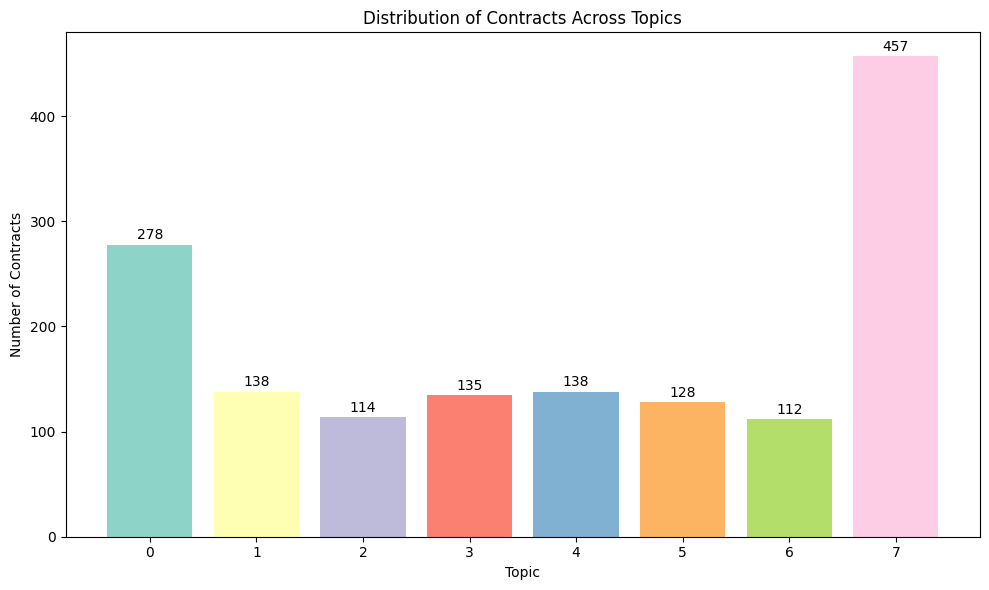

In [44]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: ...
   - Reason: ...

2. Legal topic distribution:
   - Balanced? ...
   - What this indicates: ...

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics ___ and ___ because...
   - ArXiv - Split: Topic ___ because...
   - Legal - Merge: Topics ___ and ___ because...
   - Legal - Split: Topic ___ because...

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
